<a href="https://colab.research.google.com/github/saulotorres7031-stack/Tareas1/blob/main/Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Paquetería básica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos Tensorflow y Keras
import tensorflow as tf
from tensorflow import keras

# Usamos funcionalidades básicas de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras.callbacks import ModelCheckpoint

In [2]:
!wget 'https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/BreastCancerWisconsin.csv'

--2026-03-13 04:56:39--  https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/BreastCancerWisconsin.csv
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/BreastCancerWisconsin.csv [following]
--2026-03-13 04:56:39--  https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/BreastCancerWisconsin.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 125204 (122K) [text/plain]
Saving to: ‘BreastCancerWisconsin.csv.9’

BreastCancerWiscons 100%[===================>] 122.27K

In [3]:
dataset = pd.read_csv('BreastCancerWisconsin.csv')
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
np.array(dataset)

array([[842302, 'M', 17.99, ..., 0.4601, 0.1189, nan],
       [842517, 'M', 20.57, ..., 0.275, 0.08902, nan],
       [84300903, 'M', 19.69, ..., 0.3613, 0.08758, nan],
       ...,
       [926954, 'M', 16.6, ..., 0.2218, 0.0782, nan],
       [927241, 'M', 20.6, ..., 0.4087, 0.124, nan],
       [92751, 'B', 7.76, ..., 0.2871, 0.07039, nan]], dtype=object)

Retirar columnas vacias

In [6]:
dataset = dataset.dropna(axis=1, how='all')

In [7]:
np.array(dataset)

array([[842302, 'M', 17.99, ..., 0.2654, 0.4601, 0.1189],
       [842517, 'M', 20.57, ..., 0.186, 0.275, 0.08902],
       [84300903, 'M', 19.69, ..., 0.243, 0.3613, 0.08758],
       ...,
       [926954, 'M', 16.6, ..., 0.1418, 0.2218, 0.0782],
       [927241, 'M', 20.6, ..., 0.265, 0.4087, 0.124],
       [92751, 'B', 7.76, ..., 0.0, 0.2871, 0.07039]], dtype=object)

Revisar datos faltantes

In [8]:
dataset.isna().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


Cambio salida a categorica

In [9]:
dataset['diagnosis'] = dataset['diagnosis'].map({'B': 0, 'M': 1})

Variables de entrada y salida

In [10]:
x = np.asanyarray(dataset.drop(columns=['diagnosis']))
y = np.asanyarray(dataset[['diagnosis']])
x = StandardScaler().fit_transform(x)
print(x.shape)
print(y.shape)

(569, 31)
(569, 1)


Particionar el dataset

In [11]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2,stratify=y)

Red neuronal para aprender los datos. En este caso creamos la metrica de clasificacion AUC, Accuracy,

In [12]:
def build_model():

  model = keras.Sequential()
  model.add(keras.layers.Dense(64, activation='relu', input_shape=[x.shape[1]]))
  model.add(keras.layers.Dense(32, activation='relu'))
  model.add(keras.layers.Dropout(0.3))
  model.add(keras.layers.Dense(16, activation='relu'))
  model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Dense(1, activation='sigmoid'))

  model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(),
    metrics=[
        keras.metrics.AUC()])
  return  model

In [13]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=80)

checkpoint = ModelCheckpoint(
    filepath="Cancer.keras",   # nombre del archivo
    monitor="val_loss",              # métrica que se vigila
    save_best_only=True,             # guarda solo el mejor
    save_weights_only=False,         # guarda todo el modelo
    mode="min",                      # porque queremos minimizar loss
    verbose=0
)

model = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenar la red neuronal

In [14]:
history = model.fit(xtrain, ytrain,
                    batch_size=150, epochs=1000,
                    validation_data=(xtest, ytest),
                    verbose=0, callbacks=[es,checkpoint])

loss,accuracy = model.evaluate(xtest, ytest, batch_size=150)

print("Acccuracy:", accuracy)
print("Loss:", loss)

loss,accuracy = model.evaluate(xtrain, ytrain, batch_size=150)

print("Acccuracy:", accuracy)
print("Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - auc: 0.9850 - loss: 0.1110
Acccuracy: 0.9849537014961243
Loss: 0.11102668941020966
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - auc: 0.9998 - loss: 0.0161 
Acccuracy: 0.999803900718689
Loss: 0.01607588306069374


Dibuja las curvas de aprendizaje para un mejor diagnóstico del aprendizaje

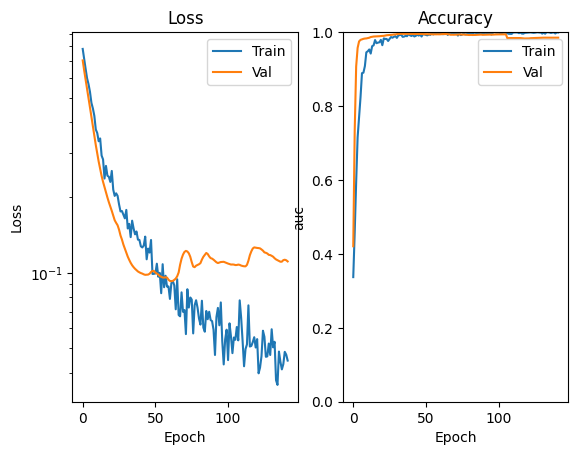

In [15]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure()
  plt.subplot(121)
  plt.title('Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Val')
  plt.yscale('log')
  plt.legend()

  plt.subplot(122)
  plt.title('Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('auc')
  plt.plot(hist['epoch'], hist['auc'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_auc'],
           label = 'Val')
  plt.ylim([0,1])
  plt.legend()
plot_history(history)